# 🖥️ Jupyter Notebook 版本 (Local Version)

> **注意：** 此版本專為本地 **Jupyter Notebook / JupyterLab** 設計，不需掛載 Google Drive。
> 請確認影像資料夾 `database/` 位於本 notebook 同一目錄下。
>
> Colab 版本請見：`0001_Image_Display.ipynb`

In [1]:
# 安裝必要套件（第一次執行時請先跑此格）
# Install required packages — run this cell first if you see ModuleNotFoundError
import sys
!{sys.executable} -m pip install opencv-python numpy matplotlib --quiet
print('✅ Packages installed. Please restart the kernel if cv2 still fails to import.')


✅ Packages installed. Please restart the kernel if cv2 still fails to import.


# 以下是必要初始設定流程

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft2, fftshift


In [3]:
# 本地版本使用相對路徑，請確保 database/ 資料夾與此 notebook 同一目錄
image_path = './database/'


## Jupyter 版本 vs Colab 版本差異說明

| 功能 | Colab 版本 | Jupyter 版本 (本檔) |
|------|------------|--------------------|
| 影像路徑 | Google Drive | 本地 `./database/` |
| 影像顯示 | `cv2_imshow(img)` | `cv2.imshow()` 或 `plt.imshow()` |
| 視窗控制 | 不支援 | 支援 `cv2.waitKey()` / `cv2.destroyAllWindows()` |
| 需要掛載 Drive | ✅ 是 | ❌ 否 |

**Jupyter 中顯示影像方式：**
- `cv2.imshow('視窗名稱', img)` → 開啟獨立視窗（需搭配 `waitKey` / `destroyAllWindows`）
- `plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))` → 在 notebook 內嵌顯示（推薦）


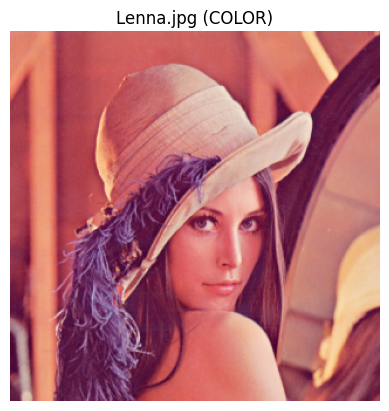

In [4]:
# 開啟圖片，預設使用 cv2.IMREAD_COLOR 模式
img = cv2.imread(image_path + 'Lenna.jpg')

# Jupyter 內嵌顯示（推薦）
plt.figure()
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Lenna.jpg (COLOR)')
plt.show()


In [ ]:
# 開啟圖片，使用 cv2.IMREAD_GRAYSCALE 模式
img_2 = cv2.imread(image_path + 'Lenna.jpg', cv2.IMREAD_GRAYSCALE)  # 0

plt.figure()
plt.imshow(img_2, cmap='gray')
plt.axis('off')
plt.title('Lenna.jpg (GRAYSCALE)')
plt.show()


In [ ]:
# 開啟圖片，使用 BGR 彩色圖像，圖像尺寸減小 1/4
img_3 = cv2.imread(image_path + 'Lenna.jpg', cv2.IMREAD_REDUCED_COLOR_4)

plt.figure()
plt.imshow(cv2.cvtColor(img_3, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Lenna.jpg (REDUCED_COLOR_4 - 1/4 size)')
plt.show()


In [ ]:
print(type(img))    # 有成功讀取到影像 → numpy.ndarray


In [ ]:
img_4 = cv2.imread(image_path + 'Lenna_.jpg')
print(type(img_4))    # 沒有成功讀取到影像 → <class 'NoneType'>


---
## ✅ 以下功能在 Jupyter 可執行（Colab 版本跳過的範例）

以下為原 Colab notebook 中標記為「Colab環境，不講述以下範例」的內容。
這些功能在本地 Jupyter 環境中皆可正常執行。


In [ ]:
# 測試開啟圖片時的按鍵指令
img = cv2.imread(image_path + 'Lenna.jpg')

cv2.imshow('img', img)               # 使用名為 img 的視窗開啟圖片
ret_value = cv2.waitKey(0)           # 按下任意鍵停止
cv2.destroyAllWindows()              # 結束所有圖片視窗
print('ret_value =', ret_value)      # 回傳值含意（按下的鍵的 ASCII 碼）


In [ ]:
# 測試開啟圖片時的視窗大小指令
img = cv2.imread(image_path + 'Lenna.jpg')

cv2.namedWindow('View1', cv2.WINDOW_NORMAL)   # 可調整大小的視窗
cv2.imshow('View1', img)               # 使用名為 View1 的視窗開啟圖片
ret_value = cv2.waitKey(0)             # 按下任意鍵停止
cv2.destroyAllWindows()                # 結束所有圖片視窗
print('ret_value =', ret_value)


In [ ]:
# ch2_1.py — matplotlib 圖表範例
import matplotlib.pyplot as plt

# 注意：在非 Windows 系統下請將 font 改為可用的中文字體
# macOS 範例：plt.rcParams["font.family"] = ["PingFang TC"]
# Linux 範例：plt.rcParams["font.family"] = ["Noto Sans CJK TC"]
# Windows：plt.rcParams["font.family"] = ["Microsoft JhengHei"]
try:
    import platform
    if platform.system() == 'Darwin':
        plt.rcParams["font.family"] = ["PingFang TC"]
    elif platform.system() == 'Windows':
        plt.rcParams["font.family"] = ["Microsoft JhengHei"]
    else:
        plt.rcParams["font.family"] = ["DejaVu Sans"]  # fallback
except Exception:
    pass

unitprice = 90                      # 一斤的價格
x = [x for x in range(1, 11)]       # x 代表斤
y = [y * unitprice for y in x]      # 不同重量的價格
plt.plot(x, y, '-*')
plt.title('玉荷包 重量 vs 價格表')
plt.xlabel('重量')
plt.ylabel('價格')
plt.show()
